# 04 Main Inequality IRFs

This is the central replication of Figure 3: dynamic responses of inequality to a 100 basis point contractionary Romer-Romer monetary policy shock.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import get_paths, ensure_output_dirs
paths = get_paths()
ensure_output_dirs(paths)


In [2]:
from src.data import load_cex_short
from src.local_projection import run_stacked_lp, lp_summary
from src.plots import FIG3_VARS, plot_irf_grid
from src.metrics import fig3_comparison, write_table

df = load_cex_short(paths)
results = {var: run_stacked_lp(df, var) for var, _, _ in FIG3_VARS}
summary = fig3_comparison(lp_summary(results))
write_table(summary, paths.tables / '04_figure3_inequality_irfs_summary.csv')
summary

,variable,p_value,f_stat,nobs,peak_irf,trough_irf,h_peak,covariance,paper_p_value,same_rejection_5pct,qualitative_note
0,D_SD_LNYBTIMP2_SA,1.807221e-12,4.937471,2163,0.032898,-0.009430,16,driscoll-kraay,0.000,True,matches 5% joint-rejection conclusion
1,D_SD_LNSALARYIMP_SA,6.035744e-04,2.325981,2163,0.018458,-0.011032,16,driscoll-kraay,0.008,True,matches 5% joint-rejection conclusion
2,D_SD_LNTOTALEXP3_SA,9.044753e-06,2.940627,2184,0.061206,0.000742,20,driscoll-kraay,0.002,True,matches 5% joint-rejection conclusion
3,D_SD_LNCONS_SA,2.045645e-04,2.490320,2184,0.034951,0.001343,20,driscoll-kraay,0.006,True,matches 5% joint-rejection conclusion
4,D_GINI_YBTIMP2_SA,1.827638e-09,4.070946,2163,0.009479,-0.004249,18,driscoll-kraay,0.000,True,matches 5% joint-rejection conclusion
5,D_GINI_SALARYIMP_SA,3.494982e-13,5.139358,2163,0.005845,-0.007452,16,driscoll-kraay,0.000,True,matches 5% joint-rejection conclusion
6,D_GINI_TOTALEXP3_SA,1.920686e-14,5.491360,2184,0.030557,0.000473,20,driscoll-kraay,0.000,True,matches 5% joint-rejection conclusion
7,D_GINI_CONS_SA,1.110223e-16,6.422916,2184,0.021652,0.001184,20,driscoll-kraay,0.000,True,matches 5% joint-rejection conclusion
8,P9010_LNYBTIMP2_SA,2.734781e-10,4.312027,2163,0.061916,-0.020738,16,driscoll-kraay,0.000,True,matches 5% joint-rejection conclusion
9,P9010_LNSALARYIMP_SA,2.140734e-02,1.727032,2163,0.063435,-0.051185,16,driscoll-kraay,0.037,True,matches 5% joint-rejection conclusion


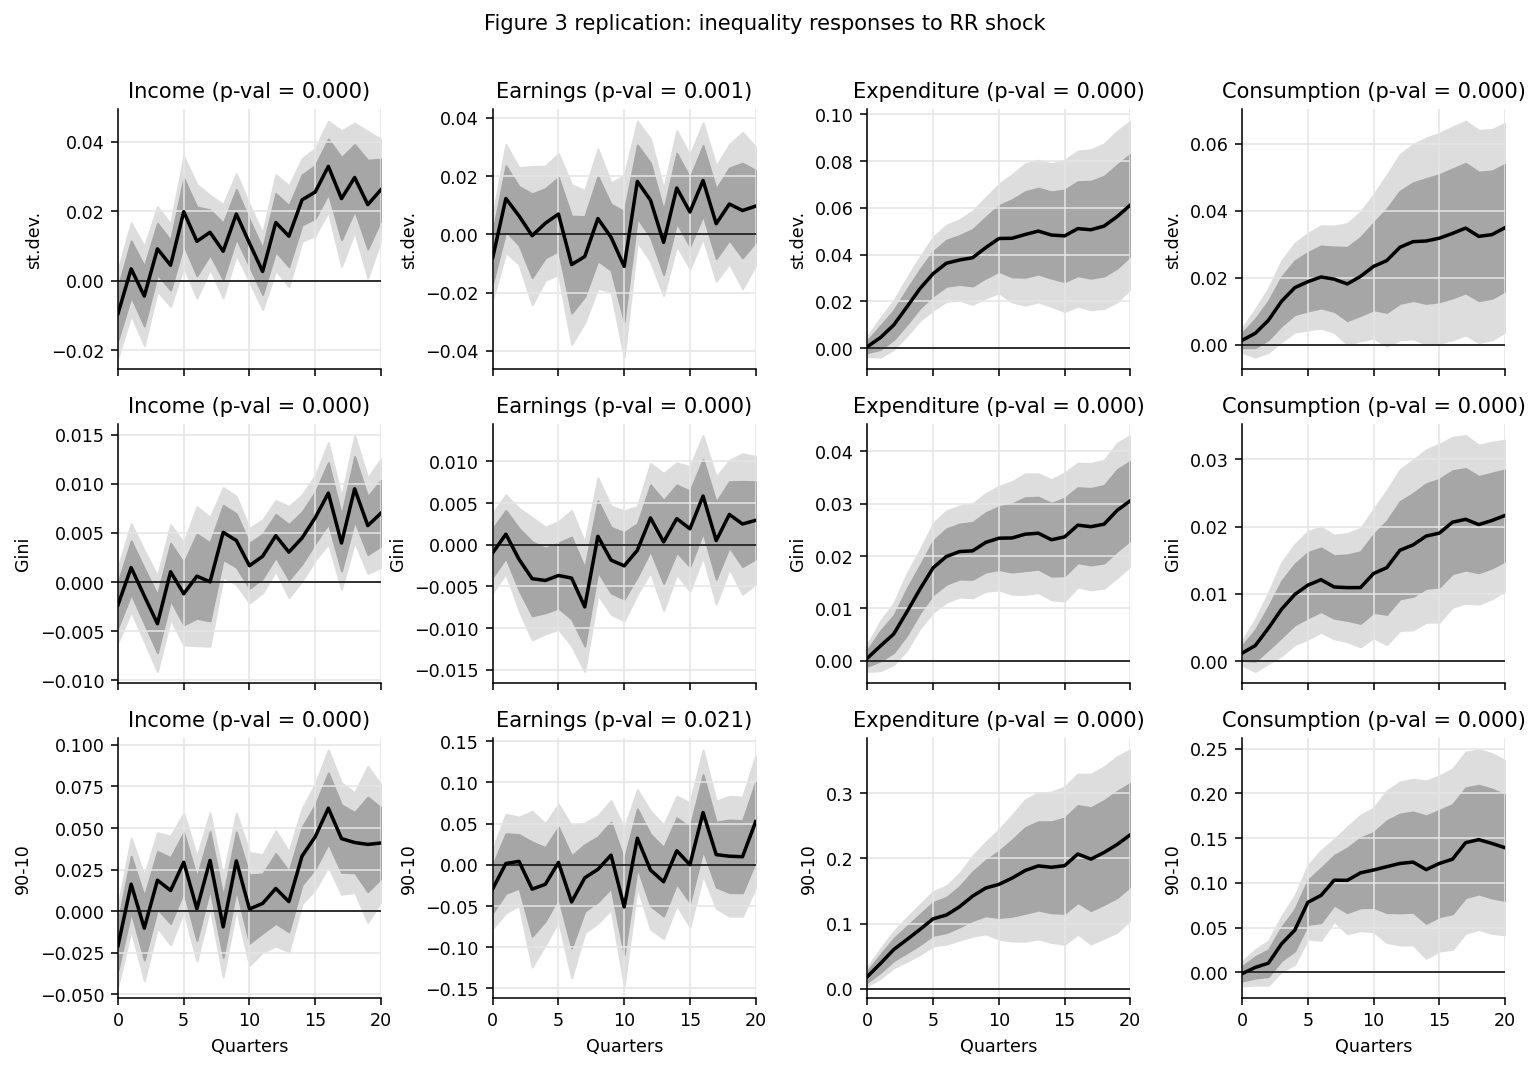

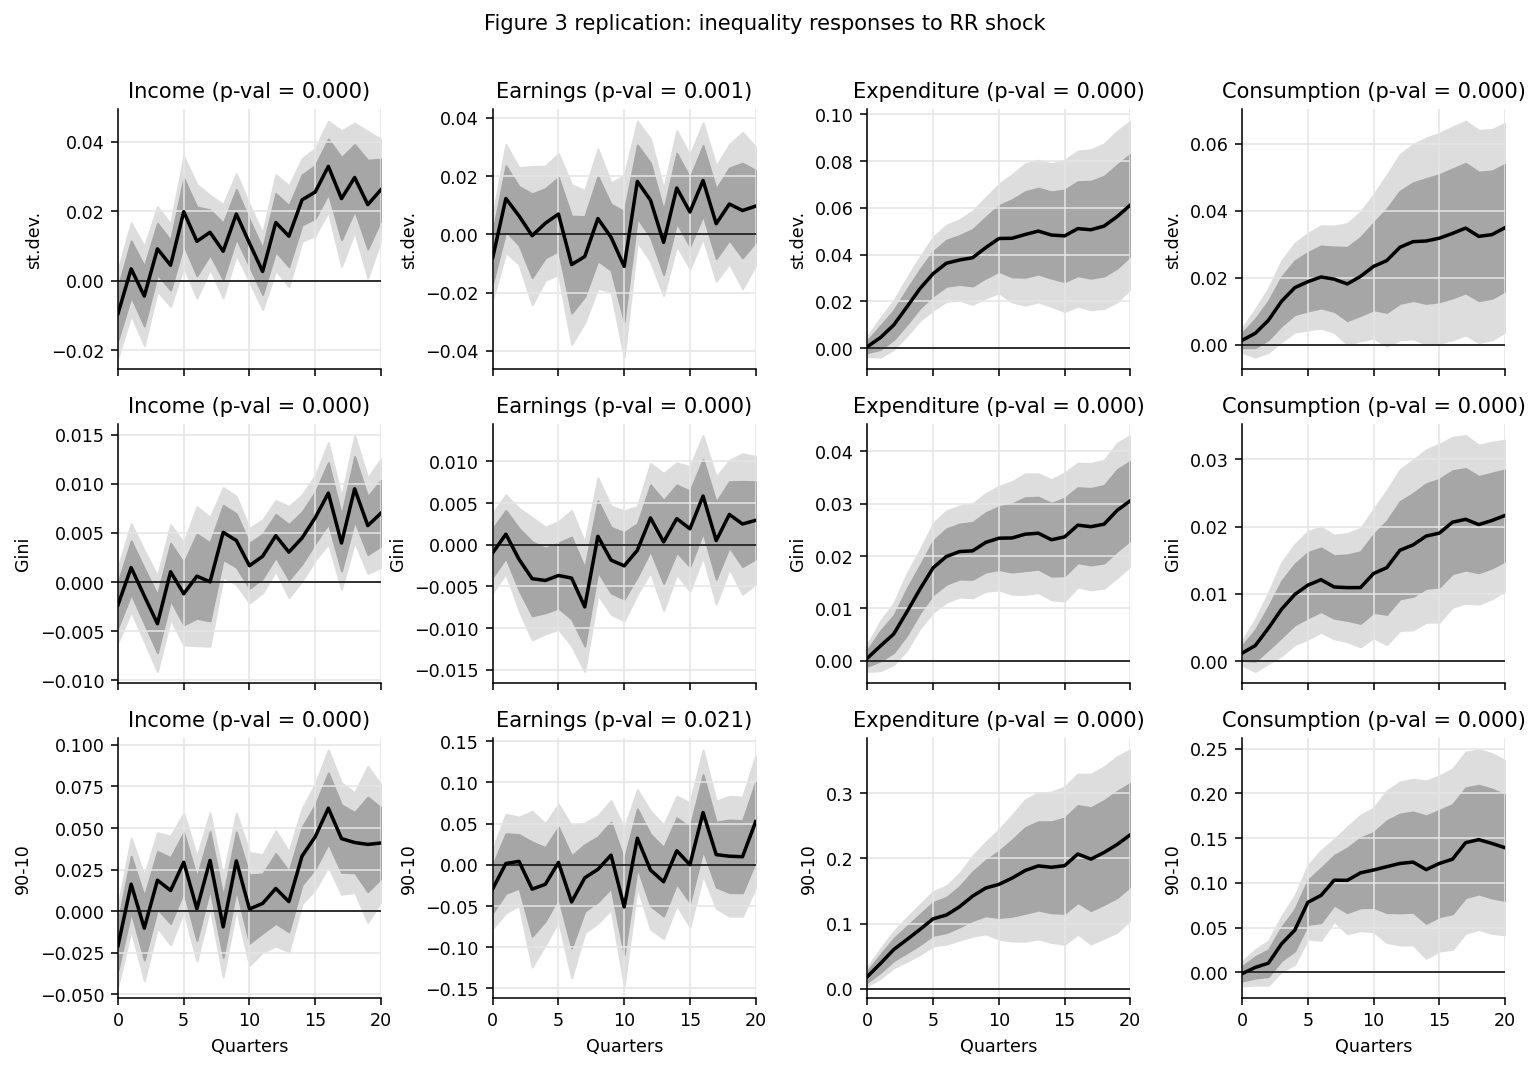

In [3]:
fig = plot_irf_grid(results, outpath=paths.figures / 'figure3_main_inequality_irfs.png', title='Figure 3 replication: inequality responses to RR shock')
fig

## Interpretation

The qualitative target is the paper's main claim: contractionary monetary policy raises income, earnings, expenditure, and consumption inequality across several inequality measures. Exact p-values may differ slightly because Stata `xtscc` and Python `linearmodels` implement Driscoll-Kraay covariance through different software paths, but the notebook records both the Python result and the published Figure 3 p-values for comparison.